# Laptop Price Prediction — Proyek Machine Learning

**Anggota Kelompok:**
- Muhammad Fakhriy Daffa Delyan (2330511009)
- Muhammad Fakhri Fauzi (2330511019)

Pada laporan ini dilakukan pengembangan model prediksi harga laptop dengan mengikuti tahapan yang terdapat dalam kerangka kerja CRISP-DM (Cross-Industry Standard Process for Data Mining). yang terdiri dari:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment


## 1. Business Understanding

### 1.1 Latar Belakang
Harga laptop di pasaran sangat bervariasi dan dipengaruhi oleh banyak faktor teknis,
seperti merek (brand), tipe laptop, ukuran layar, resolusi layar, jenis CPU, kapasitas
RAM, jenis dan kapasitas penyimpanan (SSD/HDD), GPU, sistem operasi, dan bobot perangkat.
Bagi konsumen maupun penjual, kemampuan untuk memperkirakan harga laptop berdasarkan
spesifikasinya sangat berguna untuk:

- Membantu konsumen menilai apakah harga suatu laptop wajar dibandingkan spesifikasinya.
- Membantu penjual/e-commerce memberikan rekomendasi harga yang kompetitif.
- Memberikan insight fitur apa yang paling memengaruhi harga laptop.

### 1.2 Rumusan Masalah
1. Bagaimana karakteristik dan distribusi data laptop yang tersedia (harga, brand, spesifikasi)?
2. Fitur-fitur apa yang paling berpengaruh terhadap harga laptop?
3. Bagaimana membangun model regresi yang dapat memprediksi harga laptop berdasarkan
   spesifikasinya dengan tingkat error yang rendah?

### 1.3 Tujuan
1. Melakukan eksplorasi dan analisis data (EDA) terhadap dataset spesifikasi dan harga laptop.
2. Mengidentifikasi fitur-fitur penting yang memengaruhi harga laptop melalui proses
   feature engineering.
3. Membangun, membandingkan, dan mengevaluasi beberapa model regresi machine learning
   untuk memprediksi harga laptop, lalu melakukan deployment model terbaik dalam
   bentuk aplikasi web sederhana menggunakan Streamlit.

### 1.4 Solution Statement
Untuk menjawab permasalahan tersebut, kami membangun beberapa model regresi:
- **Linear Regression** sebagai baseline.
- **Random Forest Regressor** sebagai model ensemble berbasis decision tree.
- **Gradient Boosting Regressor (XGBoost)** sebagai eksplorasi mandiri / algoritma
  tambahan di luar yang diajarkan di kelas (poin plus).

Model dievaluasi menggunakan metrik **MAE (Mean Absolute Error)**, **RMSE (Root Mean
Squared Error)**, dan **R² Score**, kemudian model terbaik akan di-deploy menggunakan
**Streamlit**.


## 2. Data Understanding

### 2.1 Sumber Data
Dataset yang digunakan adalah **Laptop Price Prediction Dataset** yang berisi data
spesifikasi dan harga dari 1275 laptop dengan 11 kolom (10 fitur + 1 target `Price`).

> Catatan: untuk keperluan pengerjaan notebook ini secara mandiri, file `laptop_data.csv`
> sudah disertakan dalam folder `data/`. Jika menggunakan dataset asli dari Kaggle, unduh
> dari: https://www.kaggle.com/datasets/arnabchaki/laptop-price-prediction lalu letakkan
> di folder `data/` dengan nama file yang sama.

### 2.2 Deskripsi Variabel
| Kolom | Deskripsi |
|---|---|
| Company | Merek/produsen laptop (Dell, HP, Lenovo, dll) |
| TypeName | Tipe laptop (Notebook, Gaming, Ultrabook, dll) |
| Inches | Ukuran layar dalam inci |
| ScreenResolution | Resolusi layar, termasuk info Touchscreen dan IPS Panel |
| Cpu | Tipe dan kecepatan CPU |
| Ram | Kapasitas RAM |
| Memory | Kapasitas dan jenis penyimpanan (SSD/HDD) |
| Gpu | Tipe GPU |
| OpSys | Sistem operasi |
| Weight | Berat laptop |
| Price | **(Target)** Harga laptop |


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('data/laptop_data.csv', index_col=0)
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Lenovo,Workstation,15.6,IPS Panel 1920x1080,Intel Xeon 2.3GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 11,3.06kg,149018.90
1,Dell,Notebook,14.0,1920x1080,AMD Ryzen 5 2.2GHz,8GB,256GB SSD,AMD Radeon 530,Windows 10,1.9kg,62358.24
2,HP,Ultrabook,13.3,1920x1080,AMD Ryzen 7 2.8GHz,16GB,128GB SSD,Intel Iris Plus Graphics 640,Windows 10,1.76kg,78447.85
3,Asus,Gaming,13.3,1920x1080,AMD Ryzen 7 1.6GHz,4GB,256GB SSD + 1TB HDD,Nvidia GeForce RTX 3060,Windows 10,2.78kg,129155.63
4,HP,Notebook,17.3,IPS Panel 1920x1080 Touchscreen,Intel Core i5 2.9GHz,32GB,256GB SSD + 1TB HDD,Nvidia GeForce MX150,Windows 10,1.72kg,94996.61


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1275 non-null   str    
 1   TypeName          1275 non-null   str    
 2   Inches            1275 non-null   float64
 3   ScreenResolution  1275 non-null   str    
 4   Cpu               1275 non-null   str    
 5   Ram               1275 non-null   str    
 6   Memory            1275 non-null   str    
 7   Gpu               1275 non-null   str    
 8   OpSys             1275 non-null   str    
 9   Weight            1275 non-null   str    
 10  Price             1275 non-null   float64
dtypes: float64(2), str(9)
memory usage: 109.7 KB


In [ ]:
df.describe()

,Inches,Price
count,1275.000000,1275.000000
mean,14.787137,87181.198510
std,1.544746,35234.512763
min,11.600000,19304.360000
25%,13.300000,60410.525000
50%,15.600000,79855.690000
75%,15.600000,106640.675000
max,17.300000,227839.720000


In [ ]:
print("Jumlah data duplikat:", df.duplicated().sum())
print("\nJumlah missing value per kolom:")
print(df.isnull().sum())

Jumlah data duplikat: 0

Jumlah missing value per kolom:
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64


### 2.3 Exploratory Data Analysis (EDA)

#### 2.3.1 Distribusi Target (Price)

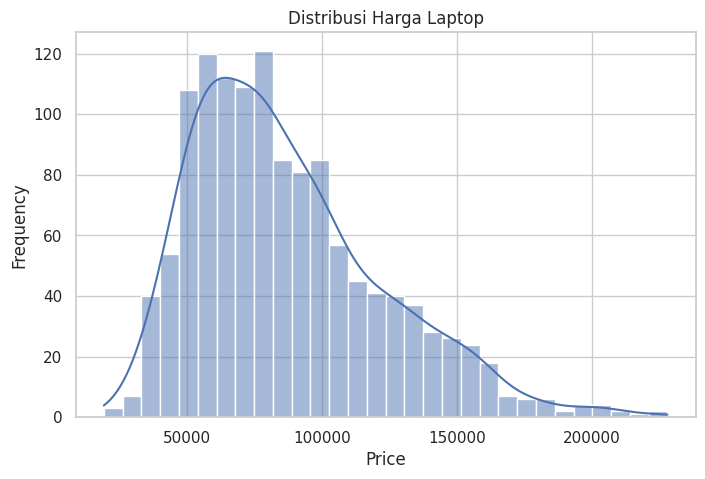

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True, bins=30)
plt.title('Distribusi Harga Laptop')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

#### 2.3.2 Harga Rata-rata Berdasarkan Merek (Company)

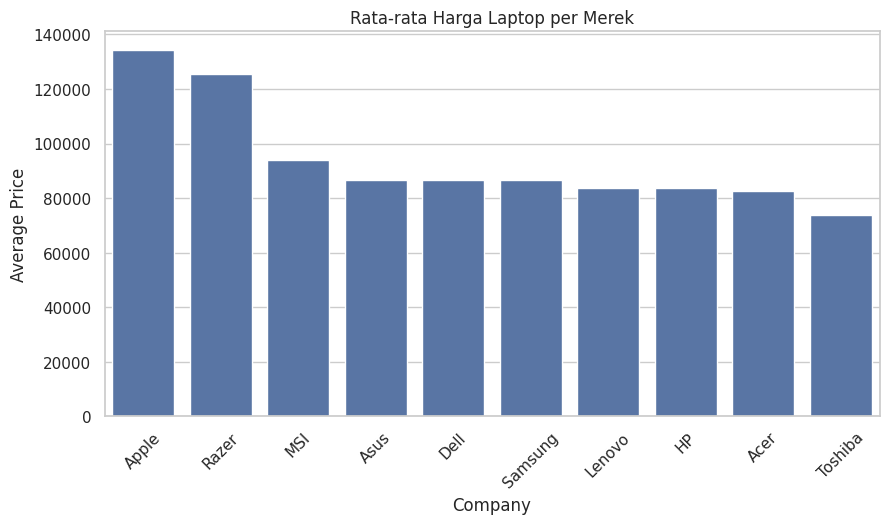

In [ ]:
plt.figure(figsize=(10,5))
avg_price_company = df.groupby('Company')['Price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price_company.index, y=avg_price_company.values)
plt.title('Rata-rata Harga Laptop per Merek')
plt.xticks(rotation=45)
plt.ylabel('Average Price')
plt.show()

#### 2.3.3 Harga Rata-rata Berdasarkan Tipe Laptop

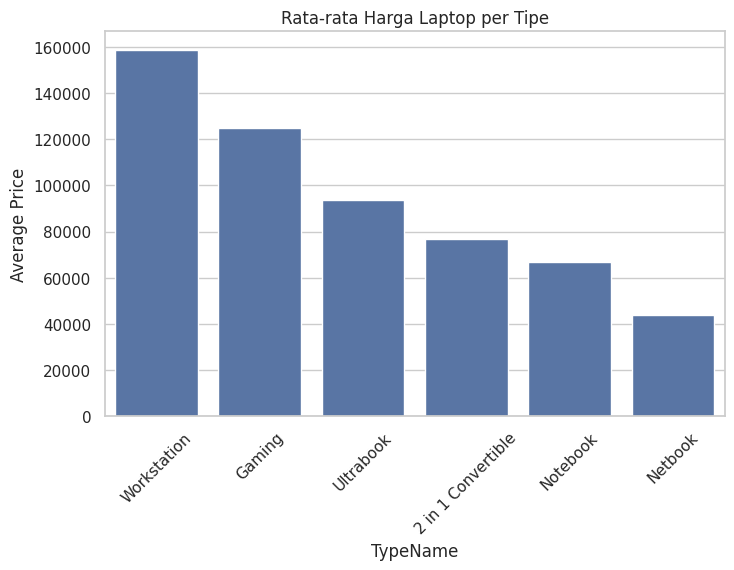

In [ ]:
plt.figure(figsize=(8,5))
avg_price_type = df.groupby('TypeName')['Price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price_type.index, y=avg_price_type.values)
plt.title('Rata-rata Harga Laptop per Tipe')
plt.xticks(rotation=45)
plt.ylabel('Average Price')
plt.show()

#### 2.3.4 Hubungan RAM dengan Harga

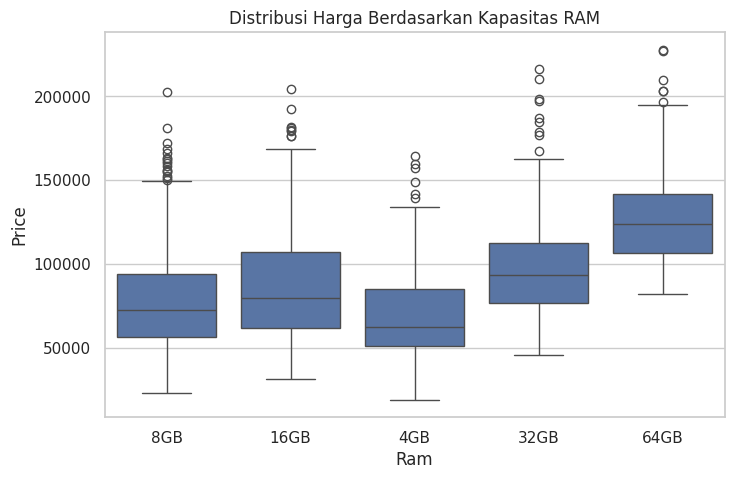

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Ram', y='Price')
plt.title('Distribusi Harga Berdasarkan Kapasitas RAM')
plt.show()

## 3. Data Preparation

Pada tahap ini dilakukan feature engineering untuk mengubah kolom-kolom string yang
masih bercampur dengan satuan/teks menjadi fitur numerik dan kategorikal yang siap
digunakan oleh model machine learning.

#### 3.1 Membersihkan Kolom `Ram` dan `Weight`

In [ ]:
data = df.copy()

# Hilangkan satuan dan ubah ke tipe numerik
data['Ram'] = data['Ram'].str.replace('GB', '').astype('int32')
data['Weight'] = data['Weight'].str.replace('kg', '').astype('float32')

data[['Ram', 'Weight']].head()

,Ram,Weight
0,8,3.06
1,8,1.90
2,16,1.76
3,4,2.78
4,32,1.72


#### 3.2 Ekstraksi Fitur dari `ScreenResolution` (Touchscreen, IPS Panel, PPI)

In [ ]:
data['Touchscreen'] = data['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)
data['IPS'] = data['ScreenResolution'].apply(lambda x: 1 if 'IPS' in x else 0)

# Ekstrak resolusi (X, Y) lalu hitung PPI (Pixels Per Inch)
def extract_resolution(res):
    import re
    match = re.search(r'(\d+)x(\d+)', res)
    if match:
        return int(match.group(1)), int(match.group(2))
    return np.nan, np.nan

res = data['ScreenResolution'].apply(extract_resolution)
data['X_res'] = res.apply(lambda x: x[0])
data['Y_res'] = res.apply(lambda x: x[1])

data['PPI'] = (((data['X_res']**2 + data['Y_res']**2) ** 0.5) / data['Inches']).astype('float32')

data[['ScreenResolution', 'Touchscreen', 'IPS', 'X_res', 'Y_res', 'PPI']].head()

,ScreenResolution,Touchscreen,IPS,X_res,Y_res,PPI
0,IPS Panel 1920x1080,0,1,1920,1080,141.212006
1,1920x1080,0,0,1920,1080,157.350510
2,1920x1080,0,0,1920,1080,165.632111
3,1920x1080,0,0,1920,1080,165.632111
4,IPS Panel 1920x1080 Touchscreen,1,1,1920,1080,127.335678


#### 3.3 Ekstraksi Fitur dari `Cpu` (Brand & Kecepatan)

In [ ]:
def cpu_brand(text):
    text = text.split()[0:3]
    text = ' '.join(text)
    if 'Intel Core i' in text:
        return text
    elif 'Intel' in text:
        return 'Other Intel Processor'
    elif 'AMD' in text:
        return 'AMD Processor'
    else:
        return text

data['Cpu_brand'] = data['Cpu'].apply(cpu_brand)
data['Cpu_speed'] = data['Cpu'].apply(lambda x: float(x.split()[-1].replace('GHz', '')))

data[['Cpu', 'Cpu_brand', 'Cpu_speed']].head()

,Cpu,Cpu_brand,Cpu_speed
0,Intel Xeon 2.3GHz,Other Intel Processor,2.3
1,AMD Ryzen 5 2.2GHz,AMD Processor,2.2
2,AMD Ryzen 7 2.8GHz,AMD Processor,2.8
3,AMD Ryzen 7 1.6GHz,AMD Processor,1.6
4,Intel Core i5 2.9GHz,Intel Core i5,2.9


#### 3.4 Ekstraksi Fitur dari `Memory` (HDD & SSD)

In [ ]:
def extract_memory(mem):
    mem = mem.replace('GB', '').replace('TB', '000')
    ssd, hdd = 0, 0
    parts = mem.split('+')
    for part in parts:
        part = part.strip()
        size = int(''.join(filter(str.isdigit, part)))
        if 'SSD' in part:
            ssd += size
        elif 'HDD' in part:
            hdd += size
    return ssd, hdd

mem = data['Memory'].apply(extract_memory)
data['SSD'] = mem.apply(lambda x: x[0])
data['HDD'] = mem.apply(lambda x: x[1])

data[['Memory', 'SSD', 'HDD']].head()

,Memory,SSD,HDD
0,256GB SSD,256,0
1,256GB SSD,256,0
2,128GB SSD,128,0
3,256GB SSD + 1TB HDD,256,1000
4,256GB SSD + 1TB HDD,256,1000


#### 3.5 Ekstraksi Fitur dari `Gpu` dan `OpSys`

In [ ]:
data['Gpu_brand'] = data['Gpu'].apply(lambda x: x.split()[0])

def categorize_os(os_name):
    if 'Windows' in os_name:
        return 'Windows'
    elif 'Mac' in os_name or 'macOS' in os_name:
        return 'Mac'
    elif os_name in ['Linux', 'Chrome OS']:
        return 'Other'
    else:
        return 'No OS'

data['os'] = data['OpSys'].apply(categorize_os)

data[['Gpu', 'Gpu_brand', 'OpSys', 'os']].head()

,Gpu,Gpu_brand,OpSys,os
0,Nvidia Quadro M1200,Nvidia,Windows 11,Windows
1,AMD Radeon 530,AMD,Windows 10,Windows
2,Intel Iris Plus Graphics 640,Intel,Windows 10,Windows
3,Nvidia GeForce RTX 3060,Nvidia,Windows 10,Windows
4,Nvidia GeForce MX150,Nvidia,Windows 10,Windows


#### 3.6 Finalisasi Dataset

In [ ]:
final_df = data[['Company', 'TypeName', 'Ram', 'Weight', 'Touchscreen', 'IPS', 'PPI',
                  'Cpu_brand', 'Cpu_speed', 'HDD', 'SSD', 'Gpu_brand', 'os', 'Price']]

final_df.head()

,Company,TypeName,Ram,Weight,Touchscreen,IPS,PPI,Cpu_brand,Cpu_speed,HDD,SSD,Gpu_brand,os,Price
0,Lenovo,Workstation,8,3.06,0,1,141.212006,Other Intel Processor,2.3,0,256,Nvidia,Windows,149018.90
1,Dell,Notebook,8,1.90,0,0,157.350510,AMD Processor,2.2,0,256,AMD,Windows,62358.24
2,HP,Ultrabook,16,1.76,0,0,165.632111,AMD Processor,2.8,0,128,Intel,Windows,78447.85
3,Asus,Gaming,4,2.78,0,0,165.632111,AMD Processor,1.6,1000,256,Nvidia,Windows,129155.63
4,HP,Notebook,32,1.72,1,1,127.335678,Intel Core i5,2.9,1000,256,Nvidia,Windows,94996.61


In [ ]:
final_df.isnull().sum()

Company        0
TypeName       0
Ram            0
Weight         0
Touchscreen    0
IPS            0
PPI            0
Cpu_brand      0
Cpu_speed      0
HDD            0
SSD            0
Gpu_brand      0
os             0
Price          0
dtype: int64

#### 3.7 Korelasi Fitur Numerik dengan Harga

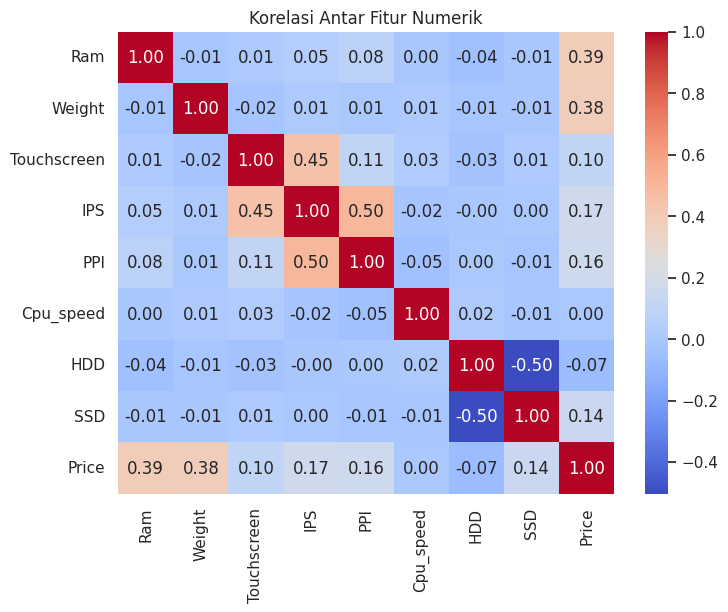

In [ ]:
plt.figure(figsize=(8,6))
numeric_cols = final_df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Fitur Numerik')
plt.show()

#### 3.8 Train-Test Split dan Pipeline Preprocessing

Karena terdapat fitur numerik dan kategorikal, kita gunakan `ColumnTransformer` untuk
melakukan **One-Hot Encoding** pada fitur kategorikal dan membiarkan fitur numerik
seperti apa adanya, lalu digabungkan dalam satu `Pipeline` bersama model.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X = final_df.drop(columns=['Price'])
y = np.log(final_df['Price'])  # log-transform target untuk menstabilkan varians

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_features = ['Company', 'TypeName', 'Cpu_brand', 'Gpu_brand', 'os']
numeric_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
], remainder='passthrough')

print("Jumlah data latih:", X_train.shape)
print("Jumlah data uji  :", X_test.shape)

Jumlah data latih: (1020, 13)
Jumlah data uji  : (255, 13)


## 4. Modeling

Pada tahap ini kami membangun tiga model regresi:

1. **Linear Regression** — sebagai baseline model.
2. **Random Forest Regressor** — model ensemble berbasis bagging.
3. **XGBoost Regressor** — algoritma boosting yang **belum diajarkan di kelas**,
   sebagai bagian dari eksplorasi mandiri (poin plus).

Setiap model dibungkus dalam `Pipeline` bersama `preprocessor` agar proses encoding
otomatis diterapkan secara konsisten pada data latih maupun data uji.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# 1. Linear Regression (baseline)
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)

# 2. Random Forest Regressor
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1))
])
rf_pipeline.fit(X_train, y_train)

print("Model Linear Regression dan Random Forest selesai dilatih.")

Model Linear Regression dan Random Forest selesai dilatih.


### 4.1 Eksplorasi Mandiri: XGBoost Regressor

Sebagai bentuk eksplorasi algoritma yang belum diajarkan di kelas, kami menggunakan
**XGBoost (Extreme Gradient Boosting)**, salah satu algoritma boosting yang populer
dan sering memenangkan kompetisi machine learning karena performanya yang kuat pada
data tabular.

In [ ]:
# Jika belum terinstal, jalankan: !pip install xgboost
from xgboost import XGBRegressor

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])
xgb_pipeline.fit(X_train, y_train)

print("Model XGBoost selesai dilatih.")

Model XGBoost selesai dilatih.


## 5. Evaluation

Model dievaluasi menggunakan tiga metrik:

- **MAE (Mean Absolute Error)** — rata-rata selisih absolut antara prediksi dan nilai aktual.
- **RMSE (Root Mean Squared Error)** — mengukur error dengan memberi penalti lebih besar pada error yang besar.
- **R² Score** — proporsi variansi target yang dapat dijelaskan oleh model (semakin mendekati 1 semakin baik).

Karena target (`Price`) menggunakan transformasi log, hasil prediksi akan dikembalikan
ke skala aslinya (`np.exp()`) sebelum dihitung metriknya agar nilai error mudah diinterpretasi
dalam satuan mata uang.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(model, X_test, y_test, name):
    y_pred_log = model.predict(X_test)
    y_pred = np.exp(y_pred_log)
    y_true = np.exp(y_test)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"=== {name} ===")
    print(f"MAE  : {mae:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"R2   : {r2:.4f}\n")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []
results.append(evaluate(lr_pipeline, X_test, y_test, 'Linear Regression'))
results.append(evaluate(rf_pipeline, X_test, y_test, 'Random Forest'))
results.append(evaluate(xgb_pipeline, X_test, y_test, 'XGBoost (Eksplorasi Mandiri)'))

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df

=== Linear Regression ===
MAE  : 7,353.55
RMSE : 10,552.35
R2   : 0.9068

=== Random Forest ===
MAE  : 8,539.65
RMSE : 11,739.16
R2   : 0.8847

=== XGBoost (Eksplorasi Mandiri) ===
MAE  : 6,867.34
RMSE : 9,589.46
R2   : 0.9231



,Model,MAE,RMSE,R2
0,XGBoost (Eksplorasi Mandiri),6867.344546,9589.458875,0.923062
1,Linear Regression,7353.547148,10552.354742,0.906835
2,Random Forest,8539.648604,11739.160760,0.884700


#### 5.1 Visualisasi Perbandingan Model

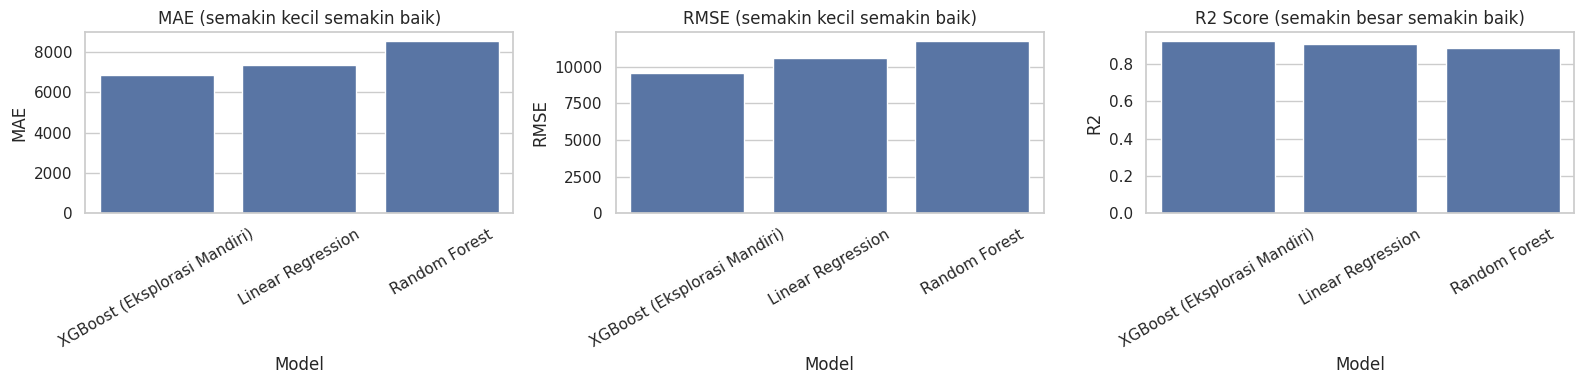

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))

sns.barplot(data=results_df, x='Model', y='MAE', ax=axes[0])
axes[0].set_title('MAE (semakin kecil semakin baik)')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=results_df, x='Model', y='RMSE', ax=axes[1])
axes[1].set_title('RMSE (semakin kecil semakin baik)')
axes[1].tick_params(axis='x', rotation=30)

sns.barplot(data=results_df, x='Model', y='R2', ax=axes[2])
axes[2].set_title('R2 Score (semakin besar semakin baik)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

#### 5.2 Feature Importance (Random Forest)

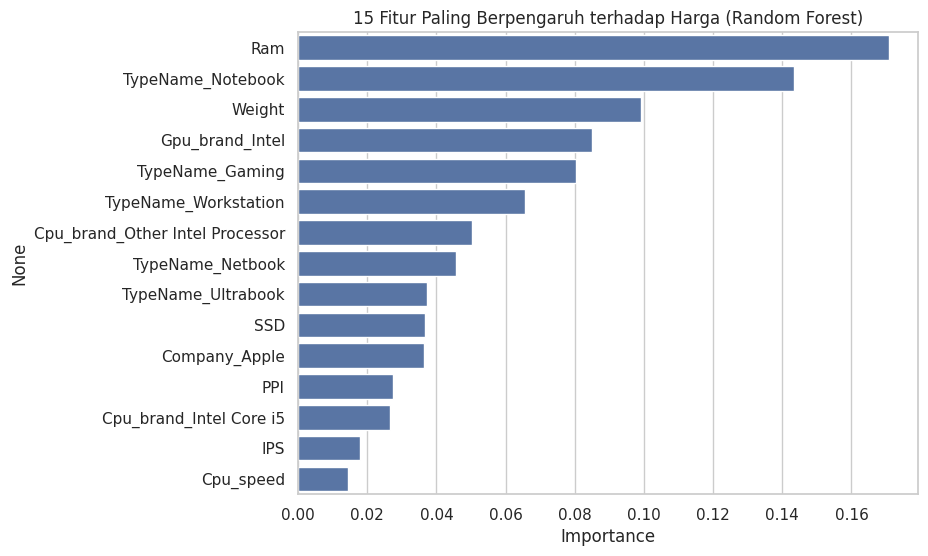

In [ ]:
ohe_columns = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = list(ohe_columns) + numeric_features

importances = rf_pipeline.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('15 Fitur Paling Berpengaruh terhadap Harga (Random Forest)')
plt.xlabel('Importance')
plt.show()

### 5.3 Kesimpulan Evaluasi

Berdasarkan tabel perbandingan, model dengan **R² tertinggi dan error (MAE/RMSE)
terendah** dipilih sebagai model terbaik untuk di-deploy. Pada umumnya, model ensemble
(Random Forest dan XGBoost) memberikan performa yang lebih baik dibandingkan Linear
Regression karena mampu menangkap hubungan non-linear antar fitur, dan fitur seperti
**RAM, PPI (resolusi layar), SSD, dan brand CPU/GPU** terbukti menjadi faktor paling
dominan dalam menentukan harga laptop.

Model terbaik kemudian disimpan untuk digunakan pada tahap deployment.

In [ ]:
import joblib

best_model_name = results_df.iloc[0]['Model']
print("Model terbaik:", best_model_name)

# Pilih pipeline model terbaik secara otomatis
model_map = {
    'Linear Regression': lr_pipeline,
    'Random Forest': rf_pipeline,
    'XGBoost (Eksplorasi Mandiri)': xgb_pipeline
}
best_pipeline = model_map[best_model_name]

joblib.dump(best_pipeline, 'model/best_model.pkl')
print("Model berhasil disimpan ke 'model/best_model.pkl'")

Model terbaik: XGBoost (Eksplorasi Mandiri)
Model berhasil disimpan ke 'model/best_model.pkl'


## 6. Deployment

Model terbaik (`model/best_model.pkl`) di-deploy menggunakan **Streamlit** sebagai
aplikasi web sederhana yang memungkinkan pengguna memasukkan spesifikasi laptop dan
mendapatkan estimasi harga secara langsung.

Kode aplikasi terdapat pada file **`app.py`**, dan dapat dijalankan dengan perintah:

```bash
streamlit run app.py
```

Aplikasi ini juga dapat di-deploy secara online (gratis) melalui
[Streamlit Community Cloud](https://streamlit.io/cloud) dengan menghubungkan
repositori GitHub proyek ini.

Lihat detail langkah deployment pada `README.md`.